**Autor:** Andrés Alejandro Rodríguez Lozano  
**Portafolio:** Portafolio de Andrés Alejandro Rodríguez Lozano

# Capítulo 5 — Drawdowns

$$DD_t = V_t/\max_{s\le t}V_s - 1$$


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT/'src'))
import portfolio_utils as pu
daily = pd.read_csv(ROOT/'data'/'precios_ajustados_diarios.csv', index_col=0, parse_dates=True)
monthly = pu.to_month_end(daily).loc[:'2026-09-30']
bt = pu.backtest_portfolio(monthly, pu.CURRENT_WEIGHTS, start='2016-01-31', end='2026-09-30', rebalance='A')
spy = pu.backtest_portfolio(monthly, {'SPY':1}, start='2016-01-31', end='2026-09-30', rebalance='N')
dd_p = bt['value']/bt['value'].cummax()-1
dd_s = spy['value']/spy['value'].cummax()-1
print('Max DD portafolio:', f'{100*dd_p.min():.2f}%')
print('Max DD SPY       :', f'{100*dd_s.min():.2f}%')


Max DD portafolio: -27.47%
Max DD SPY       : -23.93%


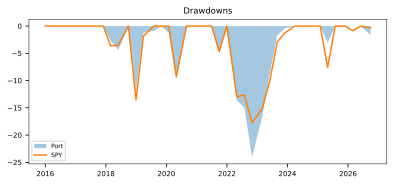

In [1]:
fig, ax = plt.subplots(figsize=(9,4))
ax.fill_between(dd_p.index, dd_p*100, 0, alpha=0.4, label='Portafolio')
ax.plot(dd_s.index, dd_s*100, label='SPY', lw=1.5)
ax.set_ylabel('%'); ax.set_title('Drawdowns'); ax.legend(); plt.tight_layout(); plt.show()


## Conclusiones
1. El portafolio asume peores caídas a cambio de mayor CAGR.

## Ejercicios
1. Duración del drawdown 2022.
2. Underwater plot solo post-COVID.
